# Spine Ultrasound 2D segmentation 
## Medical Image Analysis - Final Project - by - Tracey Li

#### Pipeline Step1: Setup imports

In [1]:

import os
import re
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import SimpleITK as sitk
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader
from monai.data import CacheDataset, decollate_batch
from monai.transforms import (
    Compose,
    MapTransform,
    EnsureChannelFirstd,
    ScaleIntensityd,
    Resized,
    EnsureTyped,
    LoadImaged
)
from monai.networks.nets import AttentionUnet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric

In [ ]:
##Block 2
DATA_ROOT = r"E:\CMU courses\2026 Spring\16725 Medical Image Analysis\final project\data\US_labeled\Extracted"   
OUTPUT_DIR = r"E:\CMU courses\2026 Spring\16725 Medical Image Analysis\final project\code\output"
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 50  ##Adjusting 50, 100, 200, 400, 800
WEIGHT_DECAY = 1e-5
IMAGE_SIZE = (768,512)
VAL_RATIO = 0.2
ALLOWED_SCAN_PREFIXES = ["R","H","D"]
MAX_SAMPLES = None
NUM_VIS_SAMPLES = 8
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("DEVICE =", DEVICE)

DEVICE = cuda


In [3]:
##Block 3 Define some functions I am going to use
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def read_mhd(path): ##this function will return to label matrix
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img) 
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]
    arr = np.squeeze(arr)
    return arr

def binarize_mask(mask): # My label is 0 and 2(foreground), so I need to transit it to 0 and 1
    return (mask > mask.min()).astype(np.float32)

def extract_subject_id(path):
    m = re.search(r"(URS\d+)", path)
    return m.group(1) if m else "UNKNOWN"

def extract_scan_group(path):  ## This function will return R or H
    m = re.search(r"URS\d+_([HRDM])\d+", path)
    return m.group(1) if m else "UNKNOWN"

set_seed(SEED)

In [4]:
##Block 4 Count samples!!
def discover_samples(data_root, allowed_scan_prefixes=None, max_samples=None):
    data_root = Path(data_root)
    label_paths = sorted(data_root.rglob("*-labels.mhd"))

    samples = []

    for label_path in label_paths:
        image_name = label_path.name.replace("-labels.mhd", ".mhd")
        image_path = label_path.with_name(image_name)

        if not image_path.exists():
            continue

        sample = {
            "image": str(image_path),
            "label": str(label_path),
            "subject_id": extract_subject_id(str(label_path)),
            "scan_group": extract_scan_group(str(label_path)),
        }
        if allowed_scan_prefixes is not None:
            if sample["scan_group"] not in allowed_scan_prefixes:
                continue

        samples.append(sample)

    if max_samples is not None:
        samples = samples[:max_samples]

    return samples

samples = discover_samples(
    DATA_ROOT,
    allowed_scan_prefixes=ALLOWED_SCAN_PREFIXES,
    max_samples=MAX_SAMPLES
)

print("Total sample number is =", len(samples))
print("First three samples are：")
for s in samples[:3]:
    print(s)

Total sample number is = 6182
First three samples are：
{'image': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US_labeled\\Extracted\\URS08_H1\\URS08_H1\\Labels\\0.mhd', 'label': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US_labeled\\Extracted\\URS08_H1\\URS08_H1\\Labels\\0-labels.mhd', 'subject_id': 'URS08', 'scan_group': 'H'}
{'image': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US_labeled\\Extracted\\URS08_H1\\URS08_H1\\Labels\\1.mhd', 'label': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US_labeled\\Extracted\\URS08_H1\\URS08_H1\\Labels\\1-labels.mhd', 'subject_id': 'URS08', 'scan_group': 'H'}
{'image': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US_labeled\\Extracted\\URS08_H1\\URS08_H1\\Labels\\10.mhd', 'label': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US

URS51 R


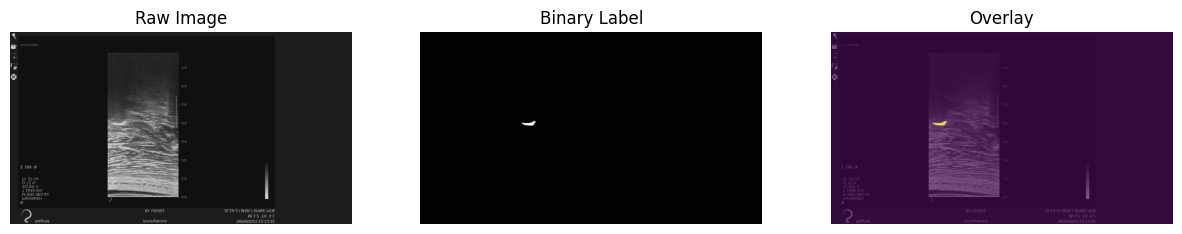

URS16 H


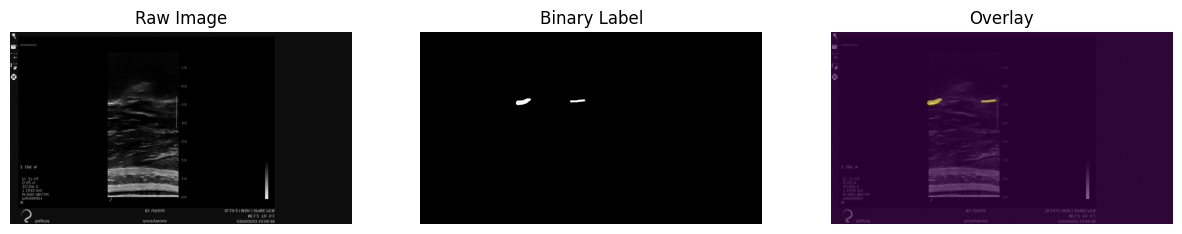

URS08 H


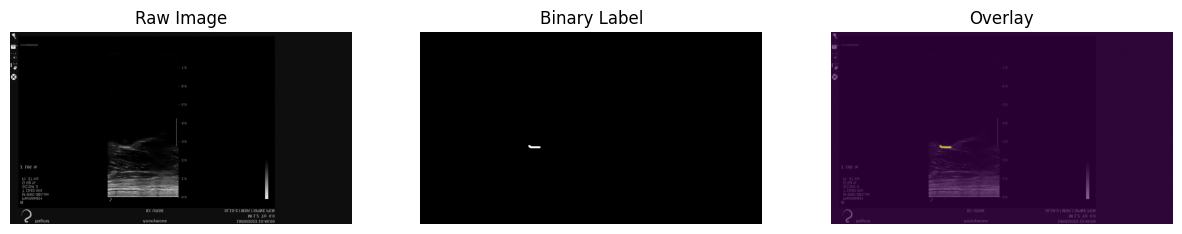

In [5]:
##Block 5 Visualize samples
def show_sample(sample):
    image = read_mhd(sample["image"])
    label = read_mhd(sample["label"])
    label_bi = binarize_mask(label)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Raw Image")
    axes[0].axis("off")

    axes[1].imshow(label_bi, cmap="gray")
    axes[1].set_title("Binary Label")
    axes[1].axis("off")

    axes[2].imshow(image, cmap="gray")
    axes[2].imshow(label_bi, alpha=0.6)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.show()

for s in random.sample(samples, min(3, len(samples))):
    print(s["subject_id"], s["scan_group"])
    show_sample(s)

In [6]:
# Block 6 Avoid data leakage and train data/test data dividing
subjects = sorted(list(set([s["subject_id"] for s in samples])))

train_subjects, val_subjects = train_test_split(
    subjects,
    test_size=VAL_RATIO, ##VAL_RATIO=0.2
    random_state=SEED
)

train_files = []
for s in samples:
    if s["subject_id"] in train_subjects:
        train_files.append(s)
val_files = []
for s in samples:
    if s["subject_id"] in val_subjects:
        val_files.append(s)

print("subjects are:", subjects)
print("Train subjects:", train_subjects)
print("Val subjects:", val_subjects)
print("Train samples:", len(train_files))
print("Val samples:", len(val_files))

subjects are: ['URS08', 'URS16', 'URS26', 'URS31', 'URS36', 'URS40', 'URS45', 'URS51', 'URS54']
Train subjects: ['URS40', 'URS08', 'URS54', 'URS26', 'URS36', 'URS31', 'URS45']
Val subjects: ['URS51', 'URS16']
Train samples: 4850
Val samples: 1332


In [ ]:
# ##Block 7 Class define: Data preparation
# class LoadMHDd(MapTransform):
#     def __init__(self, keys):
#         super().__init__(keys)
#     def __call__(self, data):
#         d = dict(data)
#         for key in self.keys:
#             arr = read_mhd(d[key]).astype(np.float32)

#             if key == "label":
#                 arr = binarize_mask(arr)

#             #CROP_BOX =(546, 206, 947, 928)  ######CROPPING IS HERE
#             CROP_BOX = None
#             if CROP_BOX is not None:
#                 y_min, y_max, x_min, x_max = CROP_BOX
#                 arr = arr[y_min:y_max, x_min:x_max]

#             d[key] = arr

#         return d
    

In [7]:
##Block 7: Updated version_taking URS31_D2 0.mhd into account
CROP_BOX = (76, 954, 501, 1008)
class LoadMHDd(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            arr = read_mhd(d[key])
            arr = np.asarray(arr)

            # 先去掉无意义维度
            arr = np.squeeze(arr)

            # image 如果是 3 通道，转成单通道
            if key == "image" and arr.ndim == 3:
                if arr.shape[-1] == 3:
                    arr = arr.mean(axis=-1)   # RGB -> 灰度
                elif arr.shape[0] == 3:
                    arr = arr.mean(axis=0)    # C,H,W -> 灰度

            # label 不应该是 3 通道
            if key == "label" and arr.ndim == 3:
                if arr.shape[-1] == 3:
                    arr = arr[..., 0]
                elif arr.shape[0] == 3:
                    arr = arr[0]

            # 最终必须保证是 2D
            if arr.ndim != 2:
                raise ValueError(f"{key} is not 2D: shape={arr.shape}, path={d[key]}")

            if key == "label":
                arr = binarize_mask(arr)

            arr = arr.astype(np.float32)
            
            if CROP_BOX is not None:
                y_min, y_max, x_min, x_max = CROP_BOX
                arr = arr[y_min:y_max, x_min:x_max]

            d[key] = arr

        return d
    

In [8]:
##test block
loader_only = LoadMHDd(keys=["image", "label"])
bad_out = loader_only(train_files[1360])
print(bad_out["image"].shape)
print(bad_out["label"].shape)

(878, 507)
(878, 507)


In [ ]:
# ##Block 8
# NUM_WORKERS = 4
# BATCH_SIZE = 4
# CACHE_RATE = 0.5

# train_transforms = Compose([
#     LoadMHDd(keys=["image", "label"]),
#     EnsureChannelFirstd(keys=["image", "label"], channel_dim="no_channel"),
#     ScaleIntensityd(keys=["image"]),
#     Resized(keys=["image"], spatial_size=IMAGE_SIZE, mode="bilinear"),
#     Resized(keys=["label"], spatial_size=IMAGE_SIZE, mode="nearest"),
#     EnsureTyped(keys=["image", "label"]),
# ])

# val_transforms = Compose([
#     LoadMHDd(keys=["image", "label"]),
#     EnsureChannelFirstd(keys=["image", "label"], channel_dim="no_channel"),
#     ScaleIntensityd(keys=["image"]),
#     Resized(keys=["image"], spatial_size=IMAGE_SIZE, mode="bilinear"),
#     Resized(keys=["label"], spatial_size=IMAGE_SIZE, mode="nearest"),
#     EnsureTyped(keys=["image", "label"]),
# ])
# train_ds = CacheDataset(
#     data=train_files,
#     transform=train_transforms,
#     cache_rate=CACHE_RATE,
#     num_workers=NUM_WORKERS,
# )

# val_ds = CacheDataset(
#     data=val_files,
#     transform=val_transforms,
#     cache_rate=CACHE_RATE,
#     num_workers=NUM_WORKERS,
# )

# train_loader = DataLoader(
#     train_ds,
#     batch_size=BATCH_SIZE,
#     shuffle=True,
#     num_workers=NUM_WORKERS,
#     pin_memory=torch.cuda.is_available(),
# )

# val_loader = DataLoader(
#     val_ds,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     num_workers=NUM_WORKERS,
#     pin_memory=torch.cuda.is_available(),
# )

# print("train ds =", len(train_ds))
# print("val ds   =", len(val_ds))


Loading dataset: 100%|██████████| 666/666 [00:09<00:00, 72.13it/s] 

train ds = 4850
val ds   = 1332


In [16]:
##Block 8 new version
from monai.data import CacheDataset, DataLoader

NUM_WORKERS = 0
BATCH_SIZE = 4
CACHE_RATE = 0.02   # 先很小，不要 0.5

train_transforms = Compose([
    LoadMHDd(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"], channel_dim="no_channel"),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=IMAGE_SIZE, mode="bilinear"),
    Resized(keys=["label"], spatial_size=IMAGE_SIZE, mode="nearest"),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadMHDd(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"], channel_dim="no_channel"),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=IMAGE_SIZE, mode="bilinear"),
    Resized(keys=["label"], spatial_size=IMAGE_SIZE, mode="nearest"),
    EnsureTyped(keys=["image", "label"]),
])

train_ds = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=CACHE_RATE,
    num_workers=NUM_WORKERS,
)

val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=CACHE_RATE,
    num_workers=NUM_WORKERS,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("train ds =", len(train_ds))
print("val ds =", len(val_ds))

Loading dataset: 100%|██████████| 26/26 [00:00<00:00, 102.29it/s]

train ds = 4850
val ds = 1332


In [39]:
# ## testing block
# bad_item = train_files[1360]
# print(bad_item)
# loader_only = LoadMHDd(keys=["image", "label"])
# bad_out = loader_only(bad_item)

# print("image type:", type(bad_out["image"]))
# print("label type:", type(bad_out["label"]))
# print("image shape:", bad_out["image"].shape)
# print("label shape:", bad_out["label"].shape)
# print("image dtype:", bad_out["image"].dtype)
# print("label dtype:", bad_out["label"].dtype)
# print("label unique:", np.unique(bad_out["label"]))

In [17]:
##Block 9
batch = next(iter(train_loader))

print("image shape =", batch["image"].shape)
print("label shape =", batch["label"].shape)
print("dtype image =", batch["image"].dtype)
print("dtype label =", batch["label"].dtype)
print(train_ds[0]["image"].shape)
print(train_ds[0]["label"].shape)

image shape = torch.Size([4, 1, 768, 512])
label shape = torch.Size([4, 1, 768, 512])
dtype image = torch.float32
dtype label = torch.float32
torch.Size([1, 768, 512])
torch.Size([1, 768, 512])


In [ ]:
##Block 10 Define the model, optimizer and dice_metric
LR = 1e-4
model = AttentionUnet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    dropout=0.1,
).to(DEVICE)

loss_function = DiceCELoss(sigmoid=True)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

dice_metric = DiceMetric(
    include_background=True,
    reduction="mean"
)

print(model)

AttentionUnet(
  (model): Sequential(
    (0): ConvBlock(
      (conv): Sequential(
        (0): Convolution(
          (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (adn): ADN(
            (N): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.1, inplace=False)
            (A): ReLU()
          )
        )
        (1): Convolution(
          (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (adn): ADN(
            (N): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.1, inplace=False)
            (A): ReLU()
          )
        )
      )
    )
    (1): AttentionLayer(
      (attention): AttentionBlock(
        (W_g): Sequential(
          (0): Convolution(
            (conv): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          )
          (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=T

In [19]:
##Block 11
images = batch["image"].to(DEVICE)

with torch.no_grad():
    outputs = model(images)

print("input :", images.shape)
print("output:", outputs.shape)

input : torch.Size([4, 1, 768, 512])
output: torch.Size([4, 1, 768, 512])


In [20]:
##Block 12

def train_one_epoch(model, loader, optimizer, loss_function, device):
    model.train()
    epoch_loss = 0

    for batch_data in tqdm(loader, desc="Train", leave=False):
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(loader)
    return epoch_loss


@torch.no_grad()
def val_one_epoch(model, loader, loss_function, dice_metric, device):
    model.eval()
    epoch_loss = 0

    dice_metric.reset()

    for batch_data in tqdm(loader, desc="Val", leave=False):
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        epoch_loss += loss.item()

        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        pred_list = decollate_batch(preds)
        label_list = decollate_batch(labels)

        dice_metric(y_pred=pred_list, y=label_list)

    epoch_loss /= len(loader)
    dice = dice_metric.aggregate().item()

    return epoch_loss, dice

In [21]:
# Block 13

best_dice = -1
train_losses = []
val_losses = []
val_dices = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_function, DEVICE)
    val_loss, val_dice = val_one_epoch(model, val_loader, loss_function, dice_metric, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    print(f"Epoch [{epoch}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Dice: {val_dice:.4f}")

    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "last_model.pt"))

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_model.pt"))
        print("保存新的 best model, best dice =", best_dice)

Epoch [1/50] Train Loss: 1.5574 | Val Loss: 1.4187 | Val Dice: 0.3519
保存新的 best model, best dice = 0.3519056439399719


Epoch [2/50] Train Loss: 1.2962 | Val Loss: 1.1865 | Val Dice: 0.5680
保存新的 best model, best dice = 0.5679939389228821


Epoch [3/50] Train Loss: 1.1208 | Val Loss: 1.0475 | Val Dice: 0.5935
保存新的 best model, best dice = 0.5934766530990601


Epoch [4/50] Train Loss: 0.9988 | Val Loss: 0.9232 | Val Dice: 0.5849


Epoch [5/50] Train Loss: 0.8540 | Val Loss: 0.7432 | Val Dice: 0.6242
保存新的 best model, best dice = 0.6241965293884277


...

Epoch [46/50] Train Loss: 0.1771 | Val Loss: 0.3881 | Val Dice: 0.6712


Epoch [47/50] Train Loss: 0.1764 | Val Loss: 0.3922 | Val Dice: 0.6674


Epoch [48/50] Train Loss: 0.1737 | Val Loss: 0.3776 | Val Dice: 0.6822


Epoch [49/50] Train Loss: 0.1739 | Val Loss: 0.3894 | Val Dice: 0.6699


Epoch [50/50] Train Loss: 0.1706 | Val Loss: 0.3924 | Val Dice: 0.6669


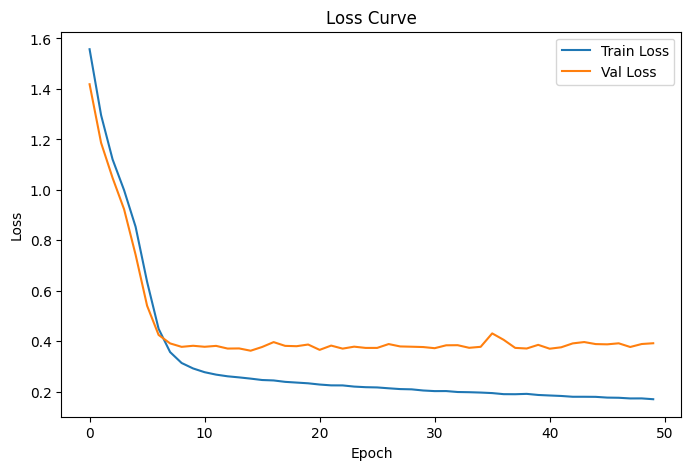

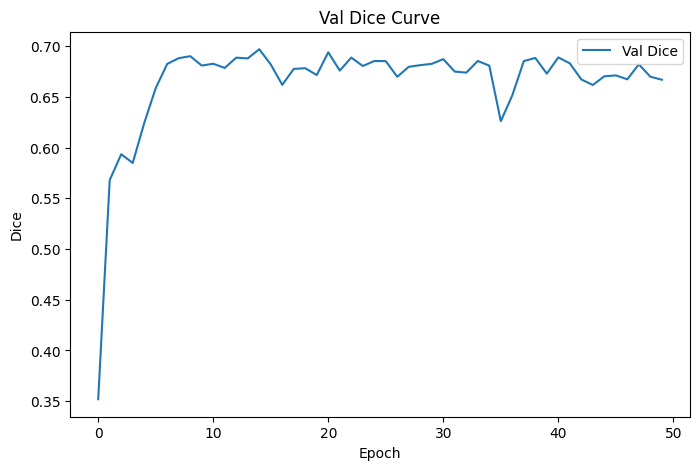

In [26]:
##Block 14 Loss and dice
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"), dpi=300)
plt.show()
plt.figure(figsize=(8, 5))
plt.plot(val_dices, label="Val Dice")
plt.title("Val Dice Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "dice_curve.png"), dpi=300)
plt.show()

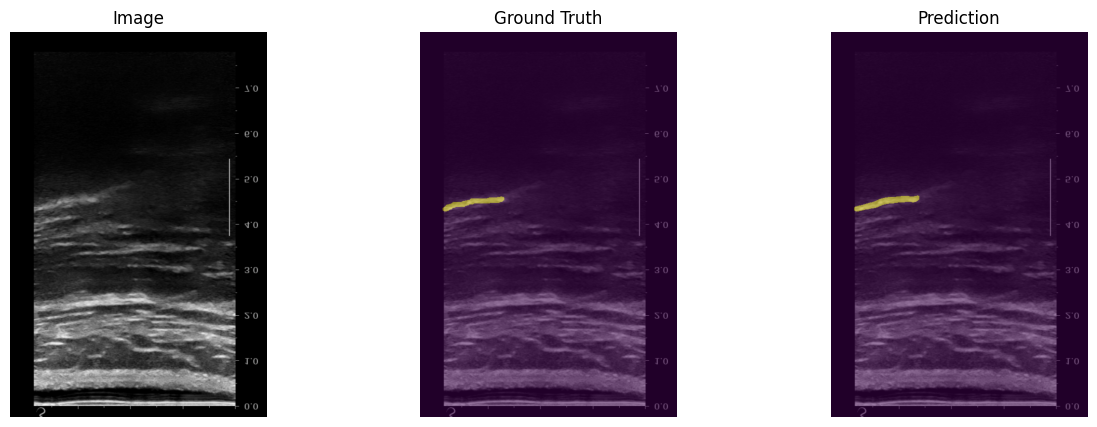

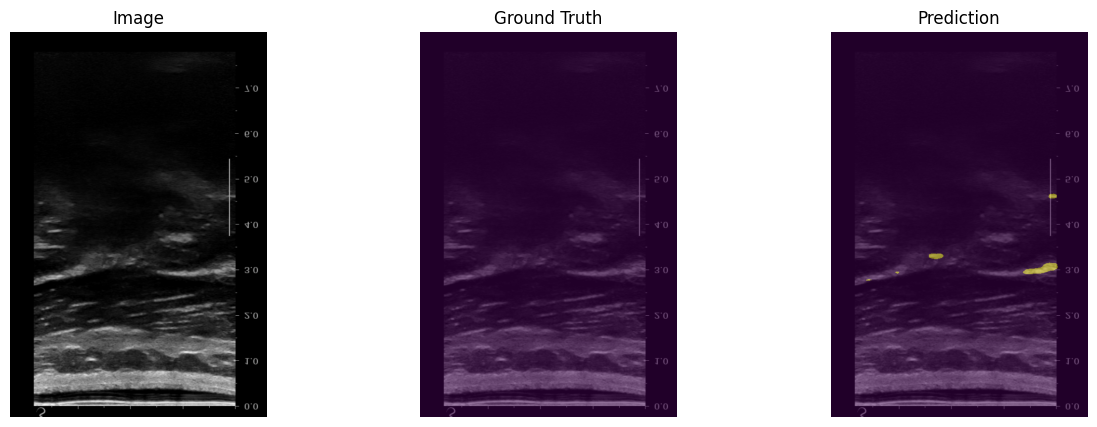

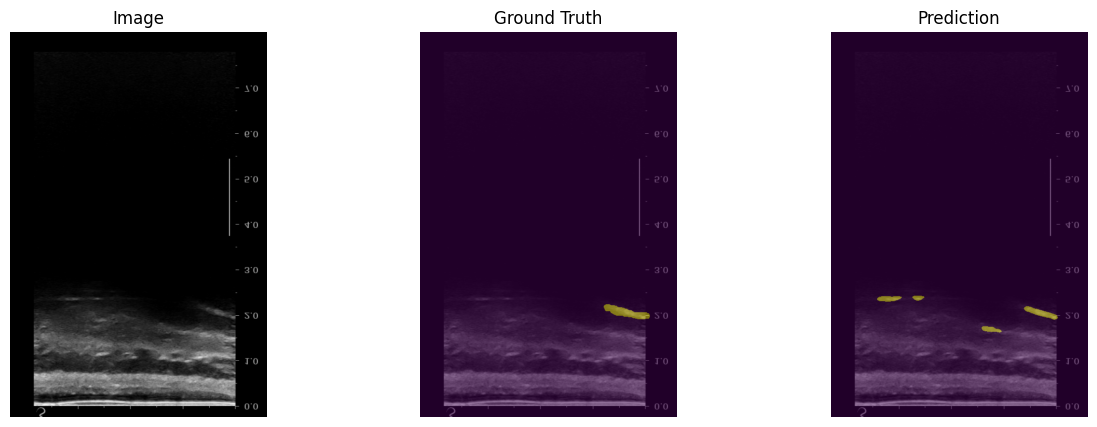

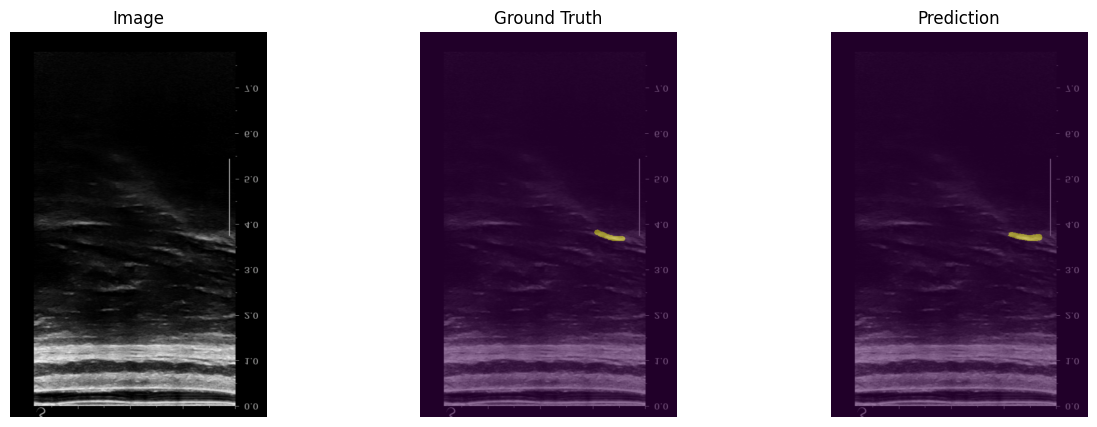

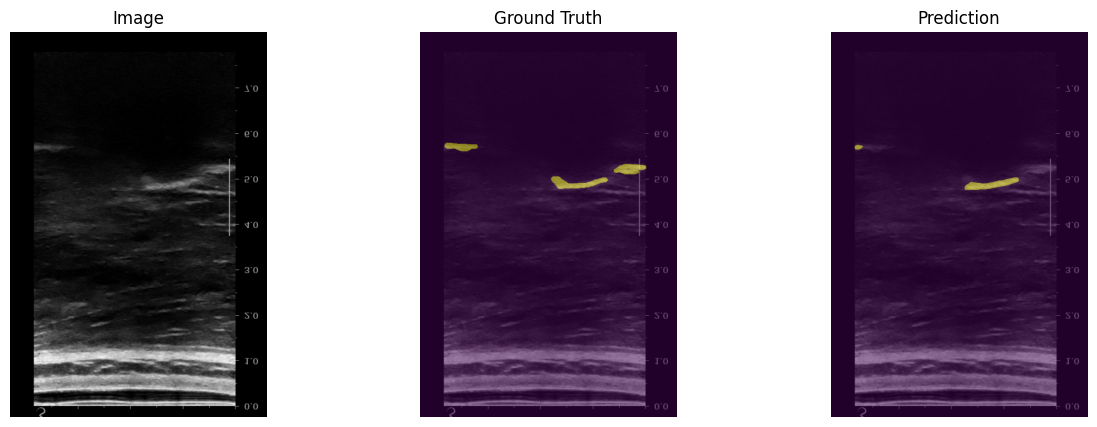

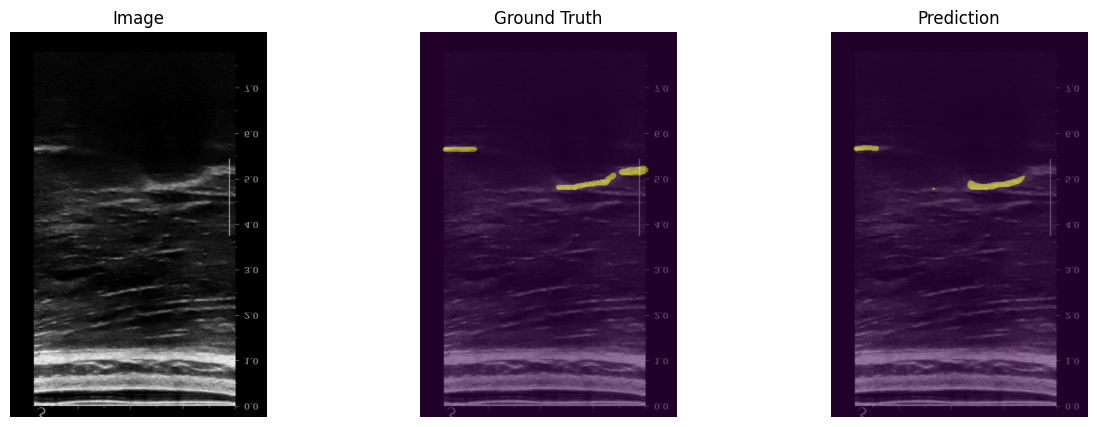

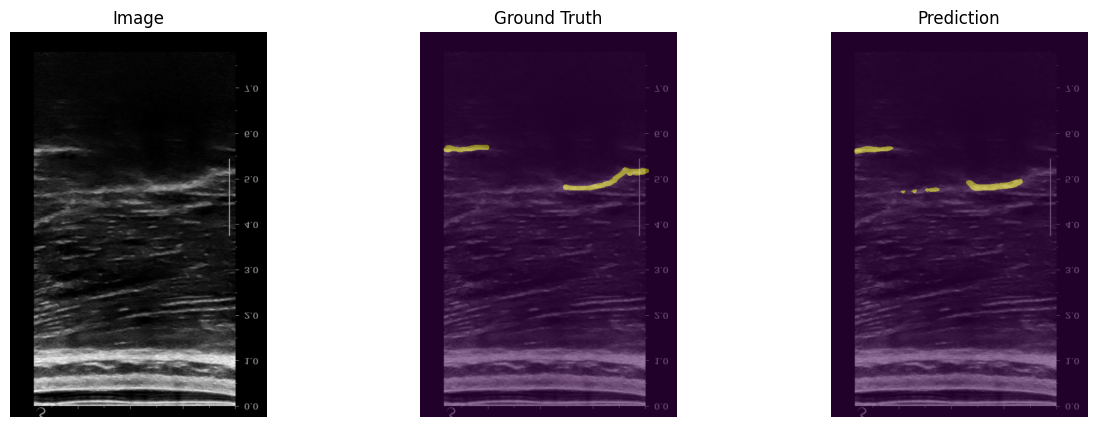

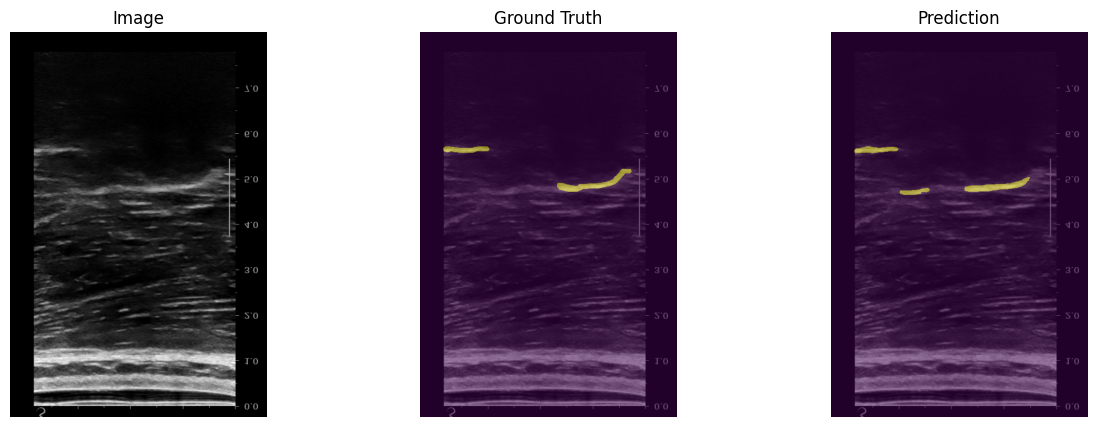

In [23]:
#Block15

model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_model.pt"), map_location=DEVICE))
model.eval()

saved = 0

with torch.no_grad():
    for batch_data in val_loader:
        inputs = batch_data["image"].to(DEVICE)
        labels = batch_data["label"].to(DEVICE)

        outputs = model(inputs)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        for i in range(inputs.shape[0]):
            img = inputs[i, 0].cpu().numpy()
            gt = labels[i, 0].cpu().numpy()
            pd = preds[i, 0].cpu().numpy()

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            axes[0].imshow(img, cmap="gray")
            axes[0].set_title("Image")
            axes[0].axis("off")

            axes[1].imshow(img, cmap="gray")
            axes[1].imshow(gt, alpha=0.5)
            axes[1].set_title("Ground Truth")
            axes[1].axis("off")

            axes[2].imshow(img, cmap="gray")
            axes[2].imshow(pd, alpha=0.5)
            axes[2].set_title("Prediction")
            axes[2].axis("off")

            plt.show()

            saved += 1
            if saved >= NUM_VIS_SAMPLES:
                break

        if saved >= NUM_VIS_SAMPLES:
            break